<a href="https://colab.research.google.com/github/sim02102955-netizen/wed_2026_bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  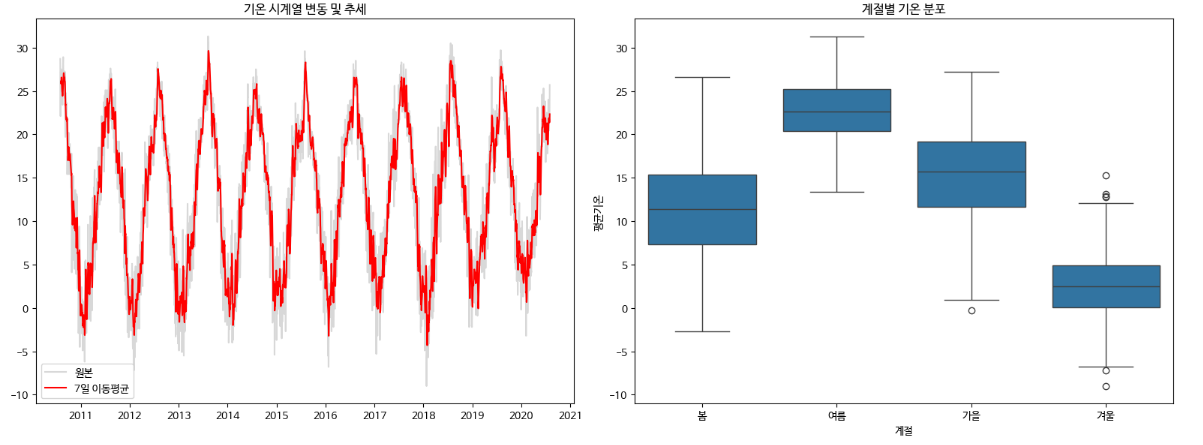

  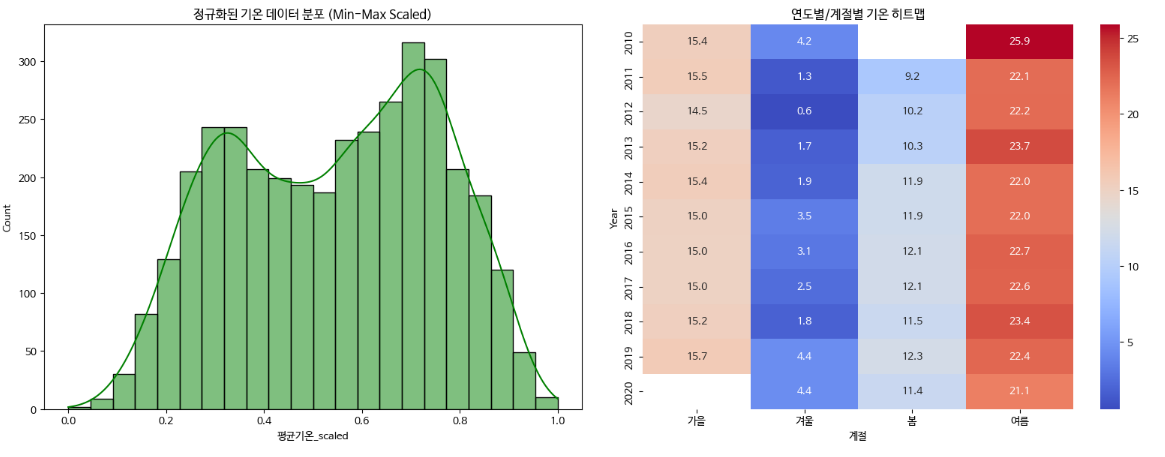



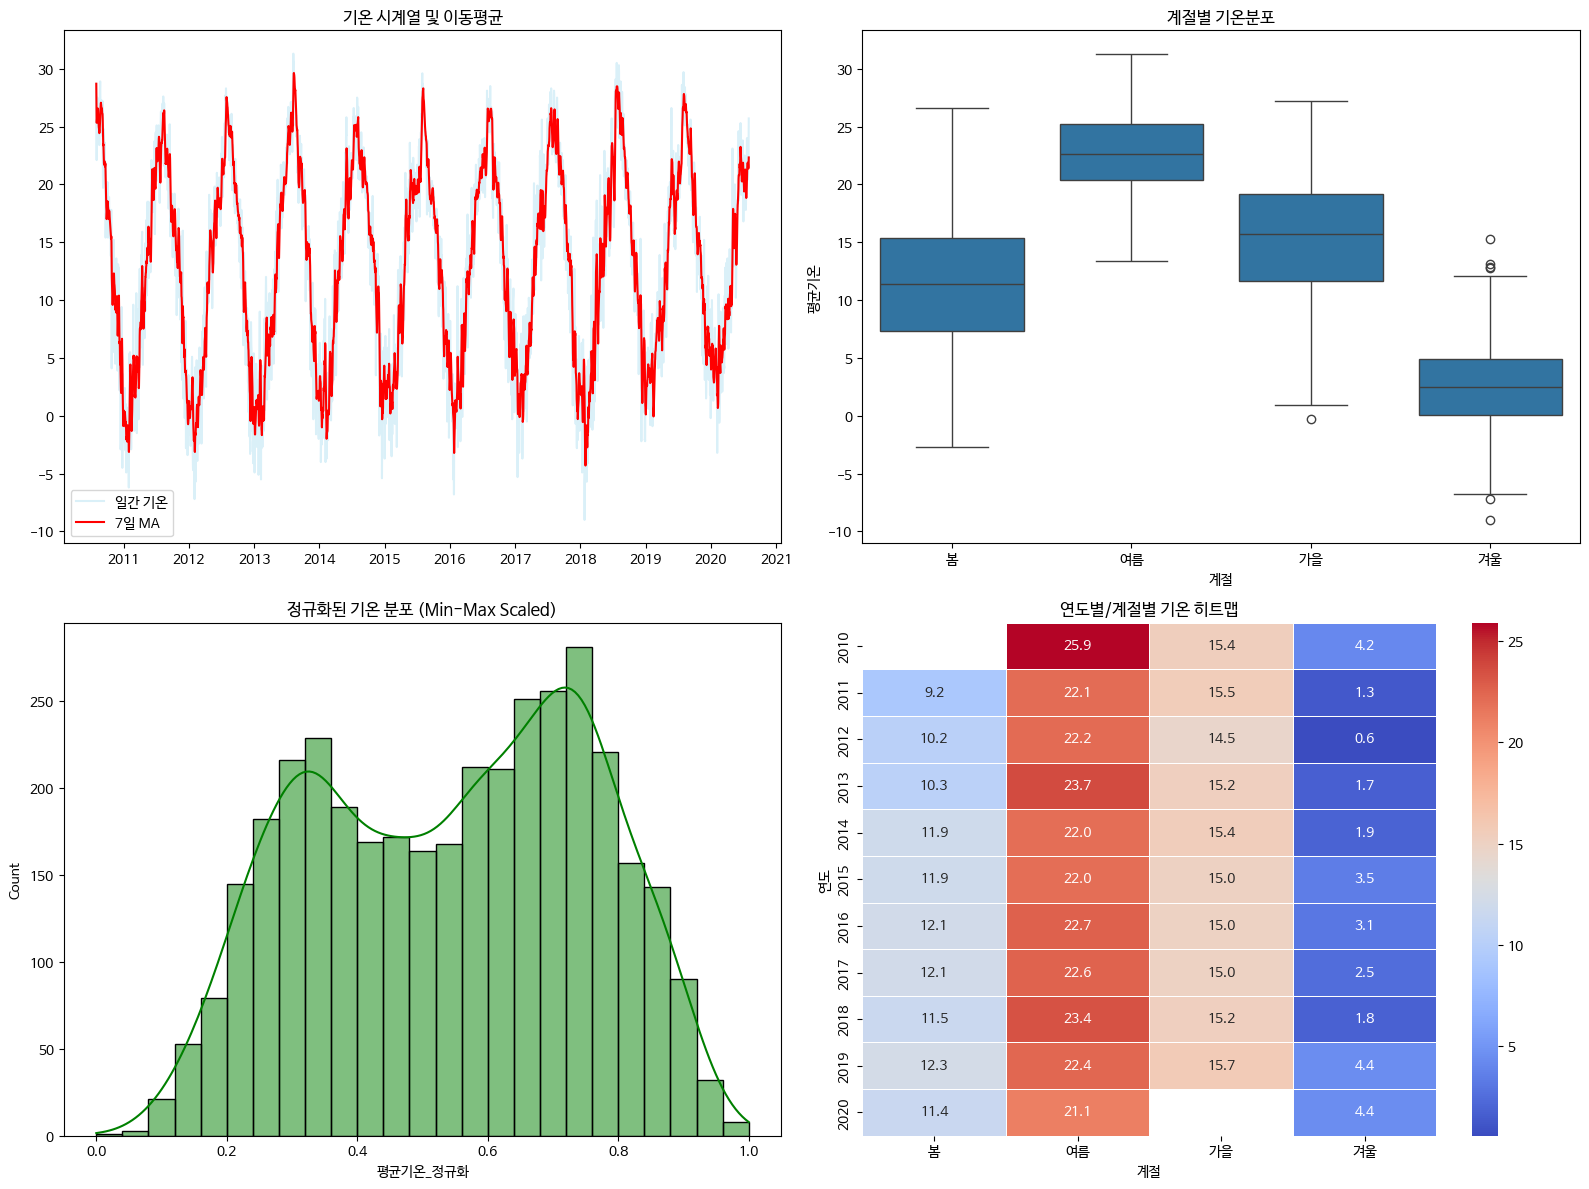

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

def setup_environment():
    warnings.filterwarnings('ignore')
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False

def handle_timeseries(data_path):
    df = pd.read_csv(data_path, encoding='CP949', on_bad_lines='skip')

    if len(df.columns) == 5:
        df.columns = ['지점', '일시', '평균기온', '최대풍속', '평균풍속']
    elif len(df.columns) == 4:
        df.columns = ['일시', '평균기온', '최대풍속', '평균풍속']

    df['일시'] = pd.to_datetime(df['일시'], errors='coerce')
    df = df.dropna(subset=['일시'])
    df = df.set_index('일시')

    if '평균기온' in df.columns:
        df['기온_7일_MA'] = df['평균기온'].rolling(window=7, min_periods=1).mean()

    return df

def apply_min_max_scaling(df):
    target_cols = ['평균기온', '최대풍속', '평균풍속']
    for col in target_cols:
        if col in df.columns:
            min_v = df[col].min()
            max_v = df[col].max()
            df[f'{col}_정규화'] = (df[col] - min_v) / (max_v - min_v)
    return df

def restructure_weather_data(df):
    df['연도'] = df.index.year
    df['월'] = df.index.month

    def get_season(month):
        if month in [3, 4, 5]: return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else: return '겨울'
    df['계절'] = df['월'].apply(get_season)

    seasonal_stats = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()

    season_order = ['봄', '여름', '가을', '겨울']
    weather_pivot = df.pivot_table(index='연도', columns='계절', values='평균기온', aggfunc='mean')
    weather_pivot = weather_pivot.reindex(columns=season_order)

    return seasonal_stats, weather_pivot

def visualize_results(df, pivot_table):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    axes[0, 0].plot(df.index, df['평균기온'], label='일간 기온', alpha=0.3, color='skyblue')
    axes[0, 0].plot(df.index, df['기온_7일_MA'], label='7일 MA', color='red')
    axes[0, 0].set_title('기온 시계열 및 이동평균')
    axes[0, 0].legend()

    sns.boxplot(x='계절', y='평균기온', data=df, ax=axes[0, 1], order=['봄', '여름', '가을', '겨울'])
    axes[0, 1].set_title('계절별 기온분포')

    sns.histplot(df['평균기온_정규화'], ax=axes[1, 0], bins=25, kde=True, color='green', edgecolor='black', alpha=0.5)
    axes[1, 0].set_title('정규화된 기온 분포 (Min-Max Scaled)')

    sns.heatmap(pivot_table, ax=axes[1, 1], annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.5)
    axes[1, 1].set_title('연도별/계절별 기온 히트맵')

    plt.tight_layout()
    plt.show()

def export_to_excel(df, seasonal_stats, pivot_table):
    filename = 'weather_analysis_report.xlsx'
    with pd.ExcelWriter(filename) as writer:
        df.to_excel(writer, sheet_name='전처리_데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절별_통계')
        pivot_table.to_excel(writer, sheet_name='연도별_피벗테이블')

def main():
    data_source = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'

    setup_environment()
    weather_df = handle_timeseries(data_source)
    weather_df = apply_min_max_scaling(weather_df)
    seasonal_stats, pivot_table = restructure_weather_data(weather_df)
    visualize_results(weather_df, pivot_table)
    export_to_excel(weather_df, seasonal_stats, pivot_table)

if __name__ == "__main__":
    main()
